In [3]:
# Cell 1 - Setup Kaggle credentials directly
import os

os.makedirs('/root/.kaggle', exist_ok=True)

# Write kaggle.json directly - no upload needed
kaggle_json = '{"username":"ahmedallii","key":"1e5be6044b8d200ecb78be9a81138fb3"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configured!")

Kaggle configured!


In [5]:
# Cell 2 - Install kaggle and download dataset
!pip install -q kaggle
!kaggle datasets download -d kazanova/sentiment140 --force
!unzip -o sentiment140.zip
!ls -lh

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 114MB/s] 

Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  
total 309M
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
-rw-r--r-- 1 root root  81M Sep 21  2019 sentiment140.zip
-rw-r--r-- 1 root root 228M Sep 21  2019 training.1600000.processed.noemoticon.csv


In [6]:
# Cell 3 - Install dependencies and import libraries
!pip install -q tensorflow nltk

import pandas as pd
import numpy as np
import re
import nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

nltk.download('stopwords')

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
# Cell 4 - Load and explore dataset
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=columns)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget value counts:")
print(df['target'].value_counts())
print("\nNull values:")
print(df.isnull().sum())

Shape: (1600000, 6)

First 5 rows:
   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  

Target value counts:
target
0    800000
4    800000
Name: count, dtype: int64

Null values:
target    0
ids       0
date      0
flag      0
u

In [8]:
# Cell 5 - Preprocess data
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower().strip()
    # Tokenize, remove stopwords and stem
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Use 200K samples for faster training (still very robust)
df_sample = df.sample(n=200000, random_state=42).reset_index(drop=True)

# Map target: 0 = negative, 1 = positive
df_sample['target'] = df_sample['target'].map({0: 0, 4: 1})

print("Cleaning tweets... this will take 2-3 minutes")
df_sample['clean_text'] = df_sample['text'].apply(clean_tweet)

print("Done!")
print(df_sample[['text', 'clean_text', 'target']].head())
print("\nTarget distribution:")
print(df_sample['target'].value_counts())

Cleaning tweets... this will take 2-3 minutes
Done!
                                                text  \
0             @chrishasboobs AHHH I HOPE YOUR OK!!!    
1  @misstoriblack cool , i have no tweet apps  fo...   
2  @TiannaChaos i know  just family drama. its la...   
3  School email won't open  and I have geography ...   
4                             upper airways problem    

                                          clean_text  target  
0                                       ahhh hope ok       0  
1                                cool tweet app razr       0  
2  know famili drama lamehey next time hang kim g...       0  
3  school email wont open geographi stuff revis s...       0  
4                               upper airway problem       0  

Target distribution:
target
1    100143
0     99857
Name: count, dtype: int64


In [9]:
# Cell 6 - Tokenize and pad sequences
MAX_VOCAB = 50000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df_sample['clean_text'])

X = tokenizer.texts_to_sequences(df_sample['clean_text'])
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
y = df_sample['target'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"y_test distribution: {np.bincount(y_test)}")

Vocabulary size: 83363
X_train shape: (160000, 50)
X_test shape: (40000, 50)
y_train distribution: [79886 80114]
y_test distribution: [19971 20029]


In [19]:
# Cell 7a - Define model
from tensorflow.keras.layers import BatchNormalization, LSTM, Bidirectional
import tensorflow.keras.backend as K

def f1_score(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(K.round(y_pred), 'float32')
    tp = K.sum(y_true * y_pred, axis=0)
    fp = K.sum((1 - y_true) * y_pred, axis=0)
    fn = K.sum(y_true * (1 - y_pred), axis=0)
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

EMBEDDING_DIM = 128

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             f1_score]
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,895,105 (26.30 MB)

 Trainable params: 6,894,337 (26.30 MB)

 Non-trainable params: 768 (3.00 KB)

In [20]:
# Cell 7b - Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]
print("Callbacks defined!")

Callbacks defined!


In [21]:
# Cell 8 - Train the model (production grade)
import time
from tensorflow.keras.callbacks import ModelCheckpoint

# Add ModelCheckpoint to callbacks
callbacks_full = callbacks + [
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Track training time
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1024,
    validation_data=(X_test, y_test),
    callbacks=callbacks_full,
    verbose=1
)

training_time = time.time() - start_time
minutes = int(training_time // 60)
seconds = int(training_time % 60)

print(f"\nTraining completed in {minutes}m {seconds}s")
print(f"Best val_accuracy:  {max(history.history['val_accuracy']):.4f}")
print(f"Best val_precision: {max(history.history['val_precision']):.4f}")
print(f"Best val_recall:    {max(history.history['val_recall']):.4f}")
print(f"Best val_f1_score:  {max(history.history['val_f1_score']):.4f}")

Epoch 1/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6332 - f1_score: 0.3348 - loss: 0.6706 - precision: 0.6304 - recall: 0.6384
Epoch 1: val_accuracy improved from None to 0.74878, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 126ms/step - accuracy: 0.7025 - f1_score: 0.3369 - loss: 0.5781 - precision: 0.7001 - recall: 0.7098 - val_accuracy: 0.7488 - val_f1_score: 0.3854 - val_loss: 0.6314 - val_precision: 0.6980 - val_recall: 0.8782 - learning_rate: 0.0010
Epoch 2/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7898 - f1_score: 0.3343 - loss: 0.4527 - precision: 0.7917 - recall: 0.7884
Epoch 2: val_accuracy improved from 0.74878 to 0.76433, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.7892 - f1_score: 0.3338 - loss: 0.4532 - precision: 0.7898 - recall: 0.7890 - val_accuracy: 0.7643 - val_f1

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.79      0.72      0.75     19971
    Positive       0.74      0.81      0.78     20029

    accuracy                           0.76     40000
   macro avg       0.77      0.76      0.76     40000
weighted avg       0.77      0.76      0.76     40000



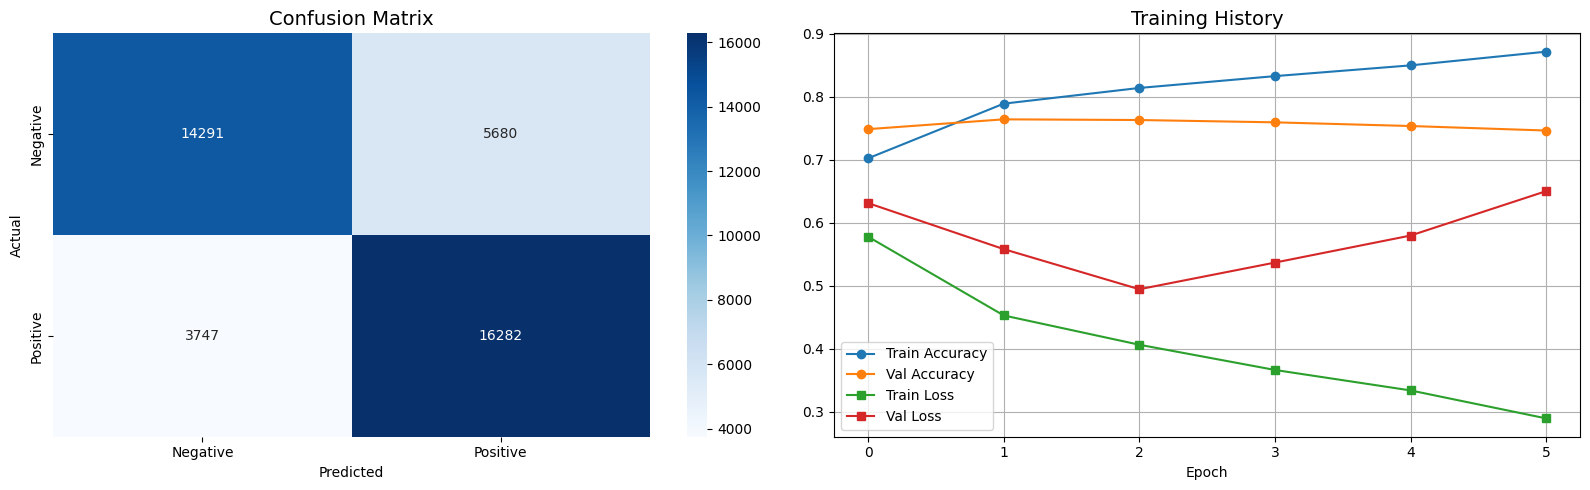

Plot saved!


In [22]:
# Cell 9 - Evaluate model and visualize results
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras', custom_objects={'f1_score': f1_score})

# Predict
y_pred_prob = best_model.predict(X_test, batch_size=1024, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2 - Training History
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[1].plot(history.history['loss'], label='Train Loss', marker='s')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Training History', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [23]:
# Cell 10 - Test with custom tweets
import pickle

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved!")

# Prediction function
def predict_sentiment(tweet, model, tokenizer):
    cleaned = clean_tweet(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    confidence = prob if prob > 0.5 else 1 - prob
    return label, confidence

# Test with sample tweets
test_tweets = [
    "I love this product, it's absolutely amazing!",
    "This is the worst experience I've ever had.",
    "Just had the best day of my life!",
    "I'm so frustrated with this service.",
    "The weather today is okay I guess."
]

print("\n" + "="*60)
print("SENTIMENT PREDICTIONS ON CUSTOM TWEETS")
print("="*60)
for tweet in test_tweets:
    label, confidence = predict_sentiment(tweet, best_model, tokenizer)
    print(f"\nTweet: {tweet}")
    print(f"Sentiment: {label} (confidence: {confidence:.2%})")

Tokenizer saved!

SENTIMENT PREDICTIONS ON CUSTOM TWEETS

Tweet: I love this product, it's absolutely amazing!
Sentiment: POSITIVE 😊 (confidence: 78.36%)

Tweet: This is the worst experience I've ever had.
Sentiment: NEGATIVE 😞 (confidence: 60.14%)

Tweet: Just had the best day of my life!
Sentiment: POSITIVE 😊 (confidence: 67.58%)

Tweet: I'm so frustrated with this service.
Sentiment: NEGATIVE 😞 (confidence: 67.22%)

Tweet: The weather today is okay I guess.
Sentiment: NEGATIVE 😞 (confidence: 53.57%)


In [24]:
# Cell - Download GloVe embeddings
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
!ls -lh glove.6B*

-rw-rw-r-- 1 root root 332M Aug  4  2014 glove.6B.100d.txt
-rw-rw-r-- 1 root root 662M Aug  4  2014 glove.6B.200d.txt
-rw-rw-r-- 1 root root 990M Aug 27  2014 glove.6B.300d.txt
-rw-rw-r-- 1 root root 164M Aug  4  2014 glove.6B.50d.txt
-rw-r--r-- 1 root root 823M Oct 25  2015 glove.6B.zip


In [25]:
# Cell - Load GloVe embeddings
import numpy as np

GLOVE_DIM = 100
GLOVE_PATH = 'glove.6B.100d.txt'

print("Loading GloVe embeddings...")
glove_embeddings = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings):,} word vectors")

# Build embedding matrix
word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

matched = 0
for word, idx in word_index.items():
    if idx < MAX_VOCAB:
        vector = glove_embeddings.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            matched += 1

coverage = matched / min(MAX_VOCAB, len(word_index)) * 100
print(f"Vocabulary matched: {matched:,} / {min(MAX_VOCAB, len(word_index)):,} ({coverage:.1f}%)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading GloVe embeddings...
Loaded 400,000 word vectors
Vocabulary matched: 19,492 / 50,000 (39.0%)
Embedding matrix shape: (50000, 100)


In [26]:
# Cell - Rebuild model with GloVe embeddings
from tensorflow.keras.layers import BatchNormalization, LSTM, Bidirectional

model_glove = Sequential([
    # GloVe Embedding - frozen, not trainable
    Embedding(input_dim=vocab_size,
              output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),

    # Bidirectional LSTM
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),
    Bidirectional(LSTM(64, dropout=0.2)),

    # Hidden layers
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    # Output
    Dense(1, activation='sigmoid')
])

model_glove.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             f1_score]
)

callbacks_glove = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='best_model_glove.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

model_glove.build(input_shape=(None, MAX_LEN))
model_glove.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 100)        │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,466,433 (20.85 MB)

 Trainable params: 465,665 (1.78 MB)

 Non-trainable params: 5,000,768 (19.08 MB)

In [28]:
# Cell - Train GloVe model
import time

start_time = time.time()

history_glove = model_glove.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1024,
    validation_data=(X_test, y_test),
    callbacks=callbacks_glove,
    verbose=1
)

training_time = time.time() - start_time
minutes = int(training_time // 60)
seconds = int(training_time % 60)

print(f"\nTraining completed in {minutes}m {seconds}s")
print(f"Best val_accuracy:  {max(history_glove.history['val_accuracy']):.4f}")
print(f"Best val_precision: {max(history_glove.history['val_precision']):.4f}")
print(f"Best val_recall:    {max(history_glove.history['val_recall']):.4f}")

Best val_recall:    0.8199


In [29]:
print(f"Best val_accuracy:  {max(history_glove.history['val_accuracy']):.4f}")
print(f"Best val_precision: {max(history_glove.history['val_precision']):.4f}")
print(f"Best val_recall:    {max(history_glove.history['val_recall']):.4f}")
print(f"Total epochs run:   {len(history_glove.history['val_accuracy'])}")

Best val_accuracy:  0.7548
Best val_precision: 0.8107
Best val_recall:    0.8199
Total epochs run:   20


In [32]:
def predict_sentiment_3class(tweet, model, tokenizer):
    cleaned = clean_tweet(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    if prob >= 0.6:
        label = "POSITIVE"
        confidence = prob
    elif prob <= 0.4:
        label = "NEGATIVE"
        confidence = 1 - prob
    else:
        label = "NEUTRAL"
        confidence = 1 - abs(prob - 0.5) * 2
    return label, confidence, prob

y_pred_prob = best_model.predict(X_test, batch_size=1024, verbose=0).flatten()
y_pred_3class = []
for prob in y_pred_prob:
    if prob >= 0.6:
        y_pred_3class.append('positive')
    elif prob <= 0.4:
        y_pred_3class.append('negative')
    else:
        y_pred_3class.append('neutral')

from collections import Counter
dist = Counter(y_pred_3class)
total = len(y_pred_3class)
print(f"Positive: {dist['positive']:,} ({dist['positive']/total*100:.1f}%)")
print(f"Negative: {dist['negative']:,} ({dist['negative']/total*100:.1f}%)")
print(f"Neutral:  {dist['neutral']:,} ({dist['neutral']/total*100:.1f}%)")

Positive: 12,800 (32.0%)
Negative: 9,454 (23.6%)
Neutral:  17,746 (44.4%)


In [33]:
tweets = [
    "I love this product absolutely amazing",
    "This is the worst experience ever",
    "Just had the best day of my life",
    "So frustrated with this service",
    "The weather today is okay I guess",
    "Not sure how I feel about this",
    "It was fine nothing special",
    "Absolutely terrible never again",
    "Pretty good overall would recommend"
]
for t in tweets:
    label, conf, prob = predict_sentiment_3class(t, best_model, tokenizer)
    print(f"{label} ({conf:.0%}) | {t}")

POSITIVE (78%) | I love this product absolutely amazing
NEGATIVE (62%) | This is the worst experience ever
POSITIVE (68%) | Just had the best day of my life
NEGATIVE (68%) | So frustrated with this service
NEUTRAL (93%) | The weather today is okay I guess
NEUTRAL (98%) | Not sure how I feel about this
POSITIVE (60%) | It was fine nothing special
NEUTRAL (80%) | Absolutely terrible never again
POSITIVE (74%) | Pretty good overall would recommend
